linear-regression-from-scratch

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
data = pd.read_csv("/content/linear_regression_100_points.csv")
data

,x,y
0,1,15
1,2,9
2,3,11
3,4,18
4,5,20
...,...,...
95,96,290
96,97,296
97,98,296
98,99,304


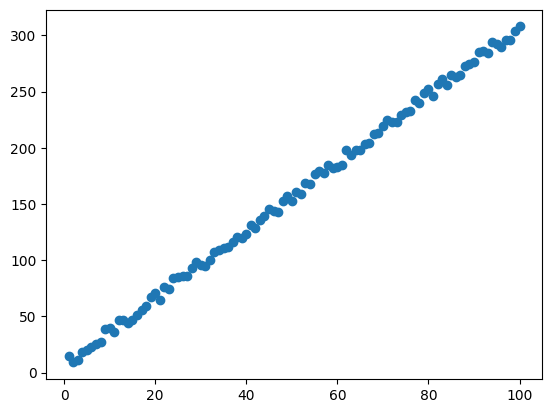

In [7]:
plt.scatter(data["x"],data["y"])
#showing data

In [9]:
#starting with loss function - though we do not use it.
def loss_function(m,b,points):
  total_error =0
  for i in range(len(points)):
    x = points.iloc[i].x
    y = points.iloc[i].y
    total_error = total_error + (y - (m*x + b))**2
  return total_error/float(len(points))

$$ L(m, b) = \frac{1}{N} \sum_{i=1}^{N} (y_i - (mx_i + b))^2 $$

We do not use it as we already have the partial derivative of this function wrt to m and b  included in the gradient descent function



---



The partial derivative of the loss function with respect to $m$ is (eq1):
$$ \frac{\partial L}{\partial m} = -\frac{2}{N} \sum_{i=1}^{N} x_i (y_i - (mx_i + b)) $$

The partial derivative of the loss function with respect to $b$ is (eq2):
$$ \frac{\partial L}{\partial b} = -\frac{2}{N} \sum_{i=1}^{N} (y_i - (mx_i + b)) $$

In [12]:
#gradient descent:
def gradient_descent(m_now,b_now,points,learning_rate):
  m_gradient = 0
  b_gradient = 0

  n = len(points)
  for i in range(n):
    x = points.iloc[i].x
    y = points.iloc[i].y
    m_gradient = m_gradient + (-2/n) * x * (y- (m_now * x + b_now)) #eq1
    b_gradient = b_gradient + (-2/n) * (y- (m_now * x + b_now)) #eq2

  m= m_now - learning_rate * m_gradient
  b= b_now - learning_rate * b_gradient
  return m,b


grdient= 3.09935848107276 and y-intercept= 0.3348829403421115


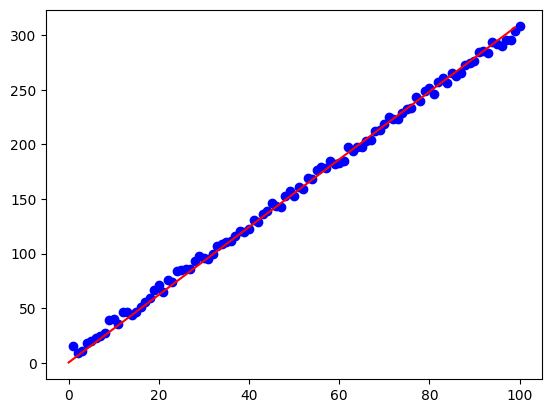

In [31]:

m=0
b=0;
l= 0.0001

for i in range(1000):
  m,b = gradient_descent(m,b,data,l)
print(f"grdient= {m} and y-intercept= {b}")

plt.scatter(data.x,data.y, color="blue")
plt.plot(list(range(100)),[m*x + b for x in range(100)],color="red")

In [22]:
#using sklearn for comparison purposes
from sklearn.linear_model import LinearRegression


In [23]:

X = data[['x']]
y = data['y']

model = LinearRegression()
model.fit(X, y)

sklearn_m = model.coef_[0]
sklearn_b = model.intercept_

print(f"sklearn gradient (m) = {sklearn_m} and sklearn y-intercept (b) = {sklearn_b}")

sklearn gradient (m) = 3.014029402940295 and sklearn y-intercept (b) = 6.051515151515076


**Calculating the Mean Squared Error for both models to evaluate performance**

In [40]:
def calculate_mse(m, b, points):
  total_error = 0
  n = len(points)
  for i in range(n):
    x = points.iloc[i].x
    y = points.iloc[i].y
    prediction = m * x + b
    total_error += (y - prediction)**2
  return total_error / n

# Calculate MSE for the custom gradient descent model
def calculate_mse_lr():
  mse_gradient_descent = calculate_mse(m, b, data)
  print(f"MSE for Custom Gradient Descent Model: {mse_gradient_descent}")
calculate_mse_lr()

# Calculate MSE for the scikit-learn model
mse_sklearn = calculate_mse(sklearn_m, sklearn_b, data)
print(f"MSE for Scikit-learn Model: {mse_sklearn}")

MSE for Custom Gradient Descent Model: 18.426427504469316
MSE for Scikit-learn Model: 10.378396279627985


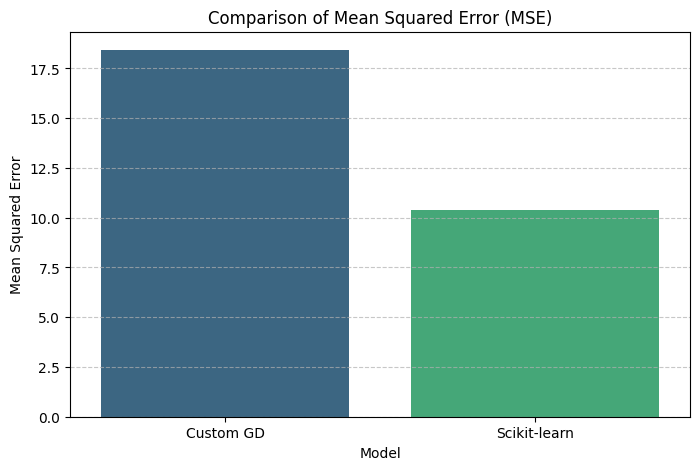

In [39]:
def output_both():
  model_names = ['Custom GD', 'Scikit-learn']
  mse_values = [mse_gradient_descent, mse_sklearn]

  plt.figure(figsize=(8, 5))
  sns.barplot(x=model_names, y=mse_values, hue=model_names, palette='viridis', legend=False)
  plt.title('Comparison of Mean Squared Error (MSE)')
  plt.xlabel('Model')
  plt.ylabel('Mean Squared Error')
  plt.grid(axis='y', linestyle='--', alpha=0.7)
  plt.show()

output_both()

## **Changing learning rate and iterations to see how it effects the results**

grdient= 3.0993585741857506 and y-intercept= 0.3348767022256981
MSE for Custom Gradient Descent Model: 18.426445068860833
MSE for Scikit-learn Model: 10.378396279627985


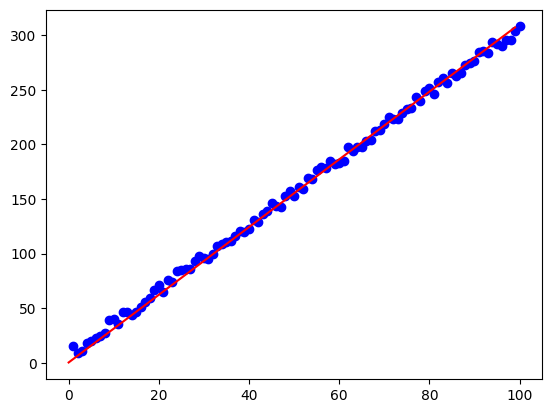

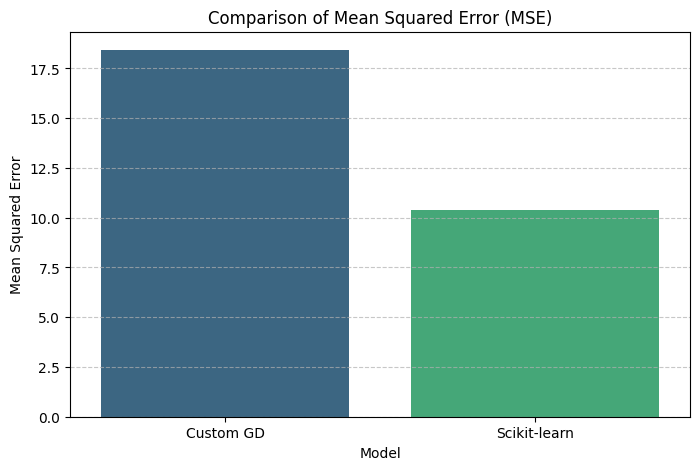

In [41]:
m=0
b=0
l= 0.00001

for i in range(10000):
  m,b = gradient_descent(m,b,data,l)
print(f"grdient= {m} and y-intercept= {b}")

plt.scatter(data.x,data.y, color="blue")
plt.plot(list(range(100)),[m*x + b for x in range(100)],color="red")

# Calculate MSE for the custom gradient descent model
mse_gradient_descent = calculate_mse(m, b, data)
print(f"MSE for Custom Gradient Descent Model: {mse_gradient_descent}")

# Calculate MSE for the scikit-learn model
mse_sklearn = calculate_mse(sklearn_m, sklearn_b, data)
print(f"MSE for Scikit-learn Model: {mse_sklearn}")
output_both()


### Explanation of the Change:

*   **Initial run:** Learning rate `l = 0.0001`, Iterations `1000`, MSE = `18.426427504469316`
*   **Second run:** Learning rate `l = 0.00001`, Iterations `10000`, MSE = `18.426445068860833`

Interestingly, despite increasing the iterations tenfold and decreasing the learning rate, the MSE for your custom gradient descent model increased very slightly. Here's why this might happen:

1.  **Local Minimum Already Reached:** It's possible that with the initial `1000` iterations and `0.0001` learning rate, your model already converged very close to a local minimum for this dataset. Further iterations, even with a smaller learning rate, might not yield significant improvements or could even cause tiny oscillations around that minimum, leading to a negligible, or in this case, slightly worse MSE due to numerical precision or a different path taken.
2.  **Too Small Learning Rate:** While a smaller learning rate can help avoid overshooting the minimum, if it's too small, it can make convergence extremely slow. Even `10,000` iterations might not be enough to traverse the error surface sufficiently with such a small step size (`0.00001`) to reach a better minimum than the previous run.
3.  **Flat Error Surface:** The error surface around the minimum might be very flat, meaning large changes in `m` and `b` lead to only tiny changes in MSE. In such cases, parameter adjustments will have minimal impact on the final MSE.

### Time Complexity of Increasing Iterations:

The gradient descent algorithm's time complexity for each iteration is directly proportional to the number of data points (`N`) in your dataset, because the gradients are calculated by summing over all `N` points. So, one iteration is `O(N)`.

If you increase the number of iterations (`K`) by a factor of 10 (e.g., from 1,000 to 10,000), the overall time complexity of the gradient descent process increases by the same factor. The total time complexity is `O(K * N)`.

In your case, going from 1,000 iterations to 10,000 iterations means the training process took approximately **10 times longer** for a very small (and in this instance, slightly negative) change in performance. This highlights the importance of finding an optimal balance between learning rate, number of iterations, and the computational cost.